# 1. Install deps

In [26]:
import sys
import os

if 'google.colab' in sys.modules:
    if not os.path.exists('/content/NLP'):
        !git clone -b lab-07 https://github.com/AndrianaNahirna/NLP.git

    %cd /content/NLP

    !pip install -r requirements.txt -q
    !git fetch origin
    !git reset --hard origin/lab-07

    sys.path.append('/content/NLP')

print("Середовище налаштовано.")

/content/NLP
remote: Enumerating objects: 5, done.
remote: Counting objects: 100% (5/5), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 5 (delta 3), reused 5 (delta 3), pack-reused 0 (from 0)
Unpacking objects: 100% (5/5), 1.13 KiB | 1.13 MiB/s, done.
From https://github.com/AndrianaNahirna/NLP
   d0037d1..3d08cac  lab-07     -> origin/lab-07
HEAD is now at 3d08cac Add threshold
Середовище налаштовано.


# 2. Data access

In [3]:
import pandas as pd

if 'google.colab' in sys.modules:
    FOLDER_ID = '1Z4ko8PYcLJOnnU98T6MTXLVYHnpMkHVK'

    # Завантаження датасету
    os.makedirs('/content/NLP/data', exist_ok=True)
    !gdown --folder https://drive.google.com/drive/folders/{FOLDER_ID} -O /content/NLP/data/

    import glob
    csv_files = glob.glob('/content/NLP/data/**/processed_v3_lemma.csv', recursive=True)

    if csv_files:
        data_path = csv_files[0]
        df = pd.read_csv(data_path)
        print(f"Датасет завантажено. Кількість рядків: {len(df)}")
    else:
        print("Файл processed_v3_lemma.csv не знайдено.")
else:
    # Локальний шлях
    df = pd.read_csv('../data/processed_v3_lemma.csv')

Retrieving folder contents
Processing file 12MwPw-0rT5kZoMFme6erhb4NeBsQxsoECoQzPuAqWcI processed_v2
Processing file 17odn4ukdHLvZKqqUuaTNPuHX66Aal-zk processed_v2.csv
Processing file 1gMJmeUiP3HXGR4P3F3Gq-eWhKkPxAbnw processed_v3_lemma.csv
Processing file 1tVj7OaRkYqaoVtmDGgDxUQ8nkDUvy7W7 raw.csv
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From (original): https://drive.google.com/uc?id=12MwPw-0rT5kZoMFme6erhb4NeBsQxsoECoQzPuAqWcI
From (redirected): https://docs.google.com/spreadsheets/d/12MwPw-0rT5kZoMFme6erhb4NeBsQxsoECoQzPuAqWcI/export?format=xlsx
To: /content/NLP/data/NLP_datasets/processed_v2
1.60MB [00:00, 58.1MB/s]
Downloading...
From: https://drive.google.com/uc?id=17odn4ukdHLvZKqqUuaTNPuHX66Aal-zk
To: /content/NLP/data/NLP_datasets/processed_v2.csv
100% 5.67M/5.67M [00:00<00:00, 53.9MB/s]
Downloading...
From: https://drive.google.com/uc?id=1gMJmeUiP3HXGR4P3F3Gq-eWhKkPxAbnw
To: /content/NLP/data/NLP_da

# 3. Load split

In [4]:
import pandas as pd

df = pd.read_csv("data/NLP_datasets/processed_v3_lemma.csv")
df['text_id'] = df.index.astype(str)

# Функція для зчитування ID з txt файлів
def load_ids(filepath):
    with open(filepath, 'r', encoding='utf-8') as f:
        return [line.strip() for line in f if line.strip()]

train_ids = load_ids("sentiment/data/sample/splits_train_ids.txt")
val_ids = load_ids("sentiment/data/sample/splits_val_ids.txt")
test_ids = load_ids("sentiment/data/sample/splits_test_ids.txt")

df_train = df[df['text_id'].isin(train_ids)]
df_val = df[df['text_id'].isin(val_ids)]
df_test = df[df['text_id'].isin(test_ids)]

print(f"Загальний розмір датасету: {len(df)}")
print(f"Розмір train: {len(df_train)}")
print(f"Розмір val: {len(df_val)}")
print(f"Розмір test: {len(df_test)}")

X_train = df_train['lemma_text']
X_val = df_val['lemma_text']
X_test = df_test['lemma_text']

# Мітки класів
y_train = df_train['target']
y_val = df_val['target']
y_test = df_test['target']

print("\nАналіз дисбалансу класів")
print("Train distribution:\n", y_train.value_counts(normalize=True))
print("Val distribution:\n", y_val.value_counts(normalize=True))
print("Test distribution:\n", y_test.value_counts(normalize=True))

Загальний розмір датасету: 3034
Розмір train: 2427
Розмір val: 303
Розмір test: 304

Аналіз дисбалансу класів
Train distribution:
 target
negative    0.633292
positive    0.366708
Name: proportion, dtype: float64
Val distribution:
 target
negative    0.633663
positive    0.366337
Name: proportion, dtype: float64
Test distribution:
 target
negative    0.634868
positive    0.365132
Name: proportion, dtype: float64


# 4. Reproduce Lab6 baseline

Відтворення найкращої моделі з ЛР6 (LogReg + TF-IDF + lemma_text + balanced)

Оцінка моделі на тестовій вибірці:
Accuracy: 0.8553
Macro-F1: 0.8407

Classification Report:
              precision    recall  f1-score   support

    negative       0.87      0.91      0.89       193
    positive       0.83      0.76      0.79       111

    accuracy                           0.86       304
   macro avg       0.85      0.83      0.84       304
weighted avg       0.85      0.86      0.85       304



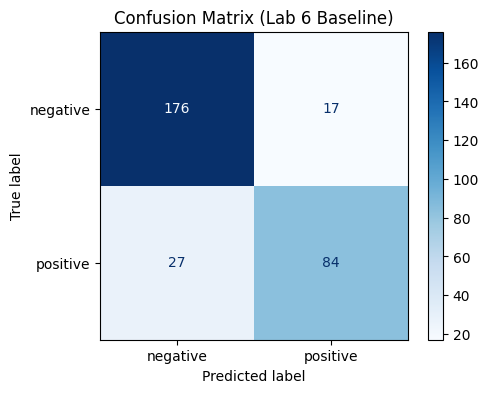

In [5]:
from sentiment.src.baseline_cls import run_logreg_baseline, evaluate_model, plot_confusion_matrix

print("Відтворення найкращої моделі з ЛР6 (LogReg + TF-IDF + lemma_text + balanced)")

# Навчаємо модель з ЛР6
pipeline_lr = run_logreg_baseline(X_train, y_train)

# Оцінюємо та отримуємо прогнози
print("\nОцінка моделі на тестовій вибірці:")
y_pred_lr = evaluate_model(pipeline_lr, X_test, y_test)

# Малюємо матрицю плутанини
plot_confusion_matrix(y_test, y_pred_lr, classes=pipeline_lr.classes_, title='Confusion Matrix (Lab 6 Baseline)')

# 5. Linear SVM baseline

Linear SVM Baseline (word-level)

Оцінка SVM (word):
Accuracy: 0.8454
Macro-F1: 0.8245

Classification Report:
              precision    recall  f1-score   support

    negative       0.84      0.94      0.89       193
    positive       0.86      0.68      0.76       111

    accuracy                           0.85       304
   macro avg       0.85      0.81      0.82       304
weighted avg       0.85      0.85      0.84       304



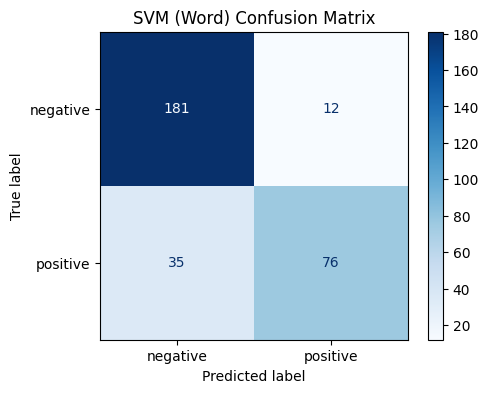

In [24]:
from sentiment.src.svm_experiments import run_linear_svm

print("Linear SVM Baseline (word-level)")
pipeline_svm_word = run_linear_svm(
    X_train, y_train,
    analyzer="word",
    ngram_range=(1, 2),
    class_weight=None
)

print("\nОцінка SVM (word):")
y_pred_svm_word = evaluate_model(pipeline_svm_word, X_test, y_test)
plot_confusion_matrix(y_test, y_pred_svm_word, classes=pipeline_svm_word.classes_, title='SVM (Word) Confusion Matrix')

# 6. Linear SVM + char-ngrams

Linear SVM Baseline (char-level)

Оцінка SVM (char):
Accuracy: 0.8322
Macro-F1: 0.8149

Classification Report:
              precision    recall  f1-score   support

    negative       0.85      0.90      0.87       193
    positive       0.80      0.72      0.76       111

    accuracy                           0.83       304
   macro avg       0.82      0.81      0.81       304
weighted avg       0.83      0.83      0.83       304



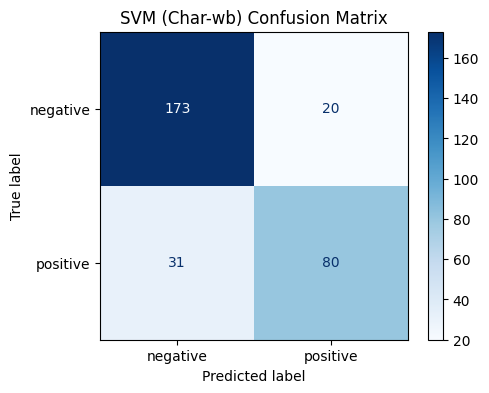

In [22]:
print("Linear SVM Baseline (char-level)")
pipeline_svm_char = run_linear_svm(
    X_train, y_train,
    analyzer="char_wb",
    ngram_range=(3, 5),
    class_weight=None
)

print("\nОцінка SVM (char):")
y_pred_svm_char = evaluate_model(pipeline_svm_char, X_test, y_test)
plot_confusion_matrix(y_test, y_pred_svm_char, classes=pipeline_svm_char.classes_, title='SVM (Char-wb) Confusion Matrix')

# 7. class_weight="balanced" comparison

class_weight='balanced' comparison

Оцінка SVM (word) + Balanced
Accuracy: 0.8454
Macro-F1: 0.8262

Classification Report:
              precision    recall  f1-score   support

    negative       0.84      0.93      0.88       193
    positive       0.85      0.70      0.77       111

    accuracy                           0.85       304
   macro avg       0.85      0.82      0.83       304
weighted avg       0.85      0.85      0.84       304



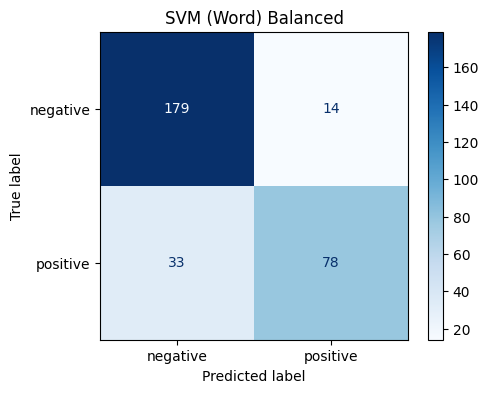


Оцінка SVM (char) + Balanced
Accuracy: 0.8257
Macro-F1: 0.8093

Classification Report:
              precision    recall  f1-score   support

    negative       0.85      0.88      0.87       193
    positive       0.78      0.73      0.75       111

    accuracy                           0.83       304
   macro avg       0.81      0.81      0.81       304
weighted avg       0.82      0.83      0.82       304



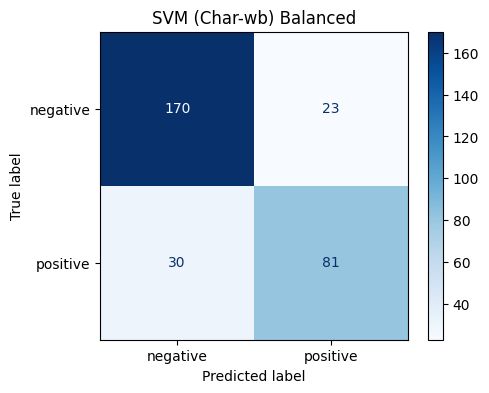

In [25]:
print("class_weight='balanced' comparison")

# Тренуємо SVM (word) з class_weight='balanced'
pipeline_svm_word_bal = run_linear_svm(
    X_train, y_train,
    analyzer="word",
    ngram_range=(1, 2),
    class_weight="balanced"
)

print("\nОцінка SVM (word) + Balanced")
y_pred_svm_word_bal = evaluate_model(pipeline_svm_word_bal, X_test, y_test)
plot_confusion_matrix(y_test, y_pred_svm_word_bal, classes=pipeline_svm_word_bal.classes_, title='SVM (Word) Balanced')

# Тренуємо SVM (char-wb) з class_weight='balanced'
pipeline_svm_char_bal = run_linear_svm(
    X_train, y_train,
    analyzer="char_wb",
    ngram_range=(3, 5),
    class_weight="balanced"
)

print("\nОцінка SVM (char) + Balanced")
y_pred_svm_char_bal = evaluate_model(pipeline_svm_char_bal, X_test, y_test)
plot_confusion_matrix(y_test, y_pred_svm_char_bal, classes=pipeline_svm_char_bal.classes_, title='SVM (Char-wb) Balanced')

### Висновок щодо class_weight="balanced"

* **Чи class_weight="balanced" реально допоміг:** Так, балансування ваг допомогло покращити загальну якість моделі. Для найкращої моделі `SVM (word)` метрика **Macro-F1 зросла з 0.8245 до 0.8262**. Хоча приріст невеликий, він показує, що модель почала краще враховувати дисбаланс класів.

* **Як саме змінились precision / recall по minority класу:**
Меншим (minority) класом у нашому датасеті є `positive`. Після додавання `class_weight="balanced"`:
  * **Recall** (повнота) для класу `positive` **зріс з 0.68 до 0.70**. Тобто модель стала частіше і краще знаходити справжні позитивні відгуки, переставши їх ігнорувати.
  * **Precision** (точність) при цьому очікувано **впав з 0.86 до 0.85**, оскільки модель стала більш "сміливою" у прогнозуванні міноритарного класу і почала допускати трохи більше хибних спрацьовувань. Загальний F1-score для цього класу зріс з 0.76 до 0.77.

* **Чи це варте втрати precision на інших класах:**
Так, це варте того. Для мажоритарного класу `negative` точність (Precision) взагалі не впала (залишилася 0.84), лише трохи знизився Recall (з 0.94 до 0.93). Загалом ми обміняли дуже незначну частку впевненості на мажоритарному класі заради кращого розпізнавання міноритарного. У задачах аналізу тональності зазвичай важливо знаходити відгуки обох типів (щоб бачити об'єктивну картину), тому таке збалансування є корисним компромісом.

# 8. PR-curve / threshold section

PR-крива для класу 'positive':


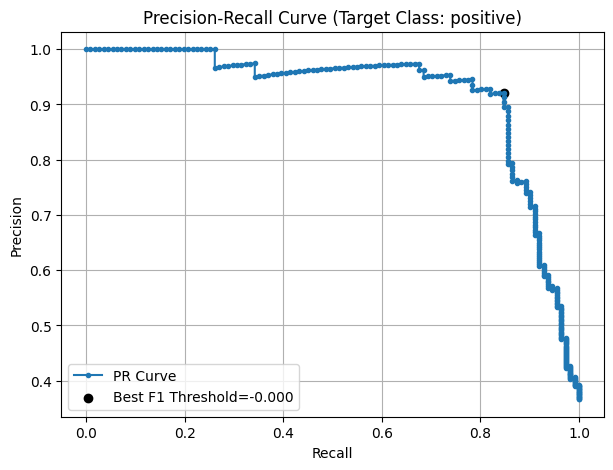


Стандартний поріг (0.000):
Classification Report (Threshold = 0.000) ---
              precision    recall  f1-score   support

    negative       0.91      0.96      0.93       192
    positive       0.92      0.84      0.88       111

    accuracy                           0.91       303
   macro avg       0.92      0.90      0.91       303
weighted avg       0.91      0.91      0.91       303


Кастомний поріг (-0.000):
Classification Report (Threshold = -0.000) ---
              precision    recall  f1-score   support

    negative       0.92      0.96      0.94       192
    positive       0.92      0.85      0.88       111

    accuracy                           0.92       303
   macro avg       0.92      0.90      0.91       303
weighted avg       0.92      0.92      0.92       303

ФІНАЛЬНА ОЦІНКА НА ТЕСТОВІЙ ВИБІРЦІ З НОВИМ ПОРОГОМ
Classification Report (Threshold = -0.000) ---
              precision    recall  f1-score   support

    negative       0.84      0.93      0.88 

In [28]:
from sentiment.src.threshold_eval import plot_pr_curve, evaluate_thresholds

# Отримуємо 'впевненість' (scores) найкращої SVM моделі
val_scores = pipeline_svm_word_bal.decision_function(X_val)

# Будуємо PR-криву для класу 'positive'
print("PR-крива для класу 'positive':")
best_thresh_val = plot_pr_curve(y_val, val_scores, pos_label='positive')

# Аналізуємо стандартний поріг (0.000 для SVM)
print("\nСтандартний поріг (0.000):")
_ = evaluate_thresholds(y_val, val_scores, threshold=0.000, pos_label='positive')

# Аналізуємо новий знайдений поріг
print(f"\nКастомний поріг ({best_thresh_val:.3f}):")
_ = evaluate_thresholds(y_val, val_scores, threshold=best_thresh_val, pos_label='positive')

# Використовуємо знайдений поріг на тестових даних
print("ФІНАЛЬНА ОЦІНКА НА ТЕСТОВІЙ ВИБІРЦІ З НОВИМ ПОРОГОМ")
test_scores = pipeline_svm_word_bal.decision_function(X_test)
y_pred_custom_thresh = evaluate_thresholds(y_test, test_scores, threshold=best_thresh_val, pos_label='positive')

In [39]:
print("Recall-first для 'positive' (Поріг = -0.5)")
print("Знижуємо поріг, щоб зловити більше позитивних відгуків (жертвуємо Precision заради Recall)")
y_pred_recall_first = evaluate_thresholds(y_test, test_scores, threshold=-0.5, pos_label='positive')

Recall-first для 'positive' (Поріг = -0.5)
Знижуємо поріг, щоб зловити більше позитивних відгуків (жертвуємо Precision заради Recall)
Classification Report (Threshold = -0.500) ---
              precision    recall  f1-score   support

    negative       0.93      0.67      0.78       193
    positive       0.61      0.92      0.74       111

    accuracy                           0.76       304
   macro avg       0.77      0.79      0.76       304
weighted avg       0.82      0.76      0.76       304



### Пояснення зміни порогу та вибір логіки

Аналізуючи результати моделі **LinearSVC (word + balanced)** на тестовій вибірці, ми бачимо класичний компроміс між точністю та повнотою для класу `positive`:

* **Як змінюється Precision:** При зниженні порогу зі стандартного `0.000` до кастомного `-0.500` точність (Precision) для позитивного класу **впала з 0.85 до 0.61**. Модель стала "оптимістичнішою" і почала допускати більше хибних спрацьовувань (False Positives), маркуючи нейтральні або негативні тексти як позитивні.
* **Як змінюється Recall:** Водночас повнота (Recall) **зросла з 0.70 до 0.92**. Зниження порогу дозволило моделі зловити майже всі справжні позитивні коментарі, суттєво зменшивши кількість пропущених хороших відгуків (False Negatives).

**Обґрунтування обраного порогу під бізнес-задачу:**

Для нашої задачі застосовано логіку **Recall-first** (поріг `-0.500`).
Цей підхід ідеальний для сценаріїв, де **пропуски (False Negatives) є дуже дорогими**.

*Приклад логіки:* Уявімо, що інтернет-магазин запускає програму автоматичного нарахування бонусів усім клієнтам, які залишили позитивний відгук. У такому разі пропустити задоволеного клієнта і не дати йому бонус (False Negative) — це ризик втратити лояльність. Тому ми свідомо знижуємо поріг: для бізнесу дешевше помилково нарахувати кілька бонусів нейтральним клієнтам (втрата Precision), аніж образити тих, хто дійсно похвалив магазин (максимізація Recall до 0.92).

*(Для порівняння: якби нашою задачею була загальна аналітика настроїв на сайті, ми б використали логіку **Балансу** зі стандартним порогом `0.000`, який забезпечує найвищий загальний F1-score).*

# 9. Confusion matrix comparison

Порівняння Confusion Matrix: ЛР6 vs ЛР7


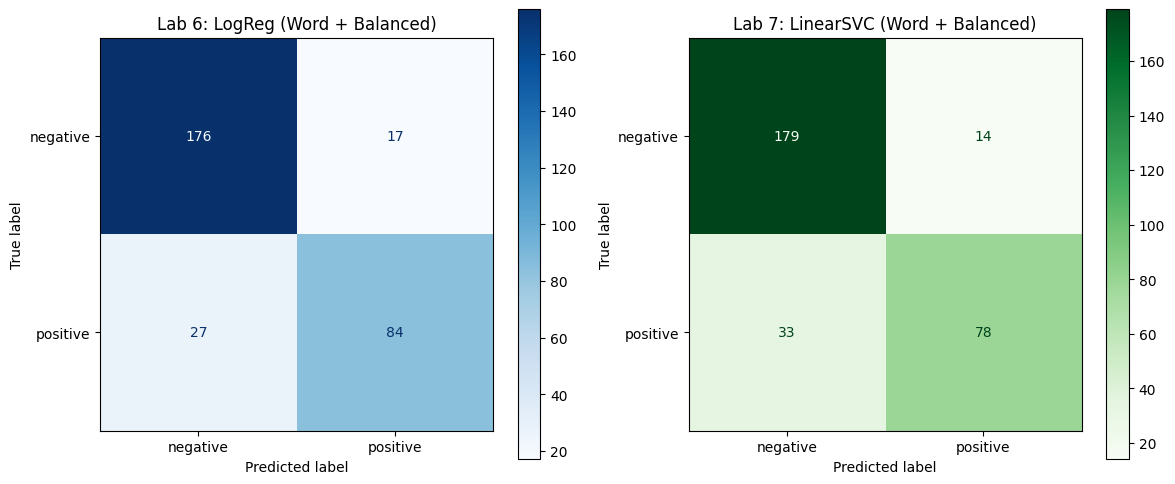


Висновок:
- Які класи плутаються найчастіше: Обидві моделі частіше помиляються, маркуючи 'positive' відгуки як 'negative' (через балансування ваг моделі стали песимістичнішими).
- Чи char-ngrams це покращили: Ні, попередні експерименти (Секції 6 та 7) показали, що char-ngrams зменшили F1-score і збільшили кількість помилок. Семантика цілих слів виявилася важливішою.


In [30]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print("Порівняння Confusion Matrix: ЛР6 vs ЛР7")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 1. Матриця з ЛР6 (LogReg + Word + Balanced)
cm_lr = confusion_matrix(y_test, y_pred_lr, labels=pipeline_lr.classes_)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=pipeline_lr.classes_)
disp_lr.plot(cmap=plt.cm.Blues, ax=axes[0], values_format='d')
axes[0].set_title('Lab 6: LogReg (Word + Balanced)')

# 2. Матриця для ЛР7 (LinearSVC + Word + Balanced)
cm_svm = confusion_matrix(y_test, y_pred_svm_word_bal, labels=pipeline_svm_word_bal.classes_)
disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=pipeline_svm_word_bal.classes_)
disp_svm.plot(cmap=plt.cm.Greens, ax=axes[1], values_format='d')
axes[1].set_title('Lab 7: LinearSVC (Word + Balanced)')

plt.tight_layout()
plt.show()

print("\nВисновок:")
print("- Які класи плутаються найчастіше: Обидві моделі частіше помиляються, маркуючи 'positive' відгуки як 'negative' (через балансування ваг моделі стали песимістичнішими).")
print("- Чи char-ngrams це покращили: Ні, попередні експерименти (Секції 6 та 7) показали, що char-ngrams зменшили F1-score і збільшили кількість помилок. Семантика цілих слів виявилася важливішою.")

У цьому розділі ми порівнюємо матриці плутанини для базової моделі з попередньої лабораторної роботи та найкращої моделі, отриманої у ЛР7.

Для порівняння було обрано:
1.  **Baseline з ЛР6:** Модель Logistic Regression на рівні слів із балансуванням класів (TfidfVectorizer word n-grams (1,2) + Logistic Regression `balanced`).
2.  **Найкраща SVM-модель з ЛР7:** Модель LinearSVC на рівні слів із балансуванням класів (TfidfVectorizer word n-grams (1,2) + LinearSVC `balanced`), оскільки вона показала вищий F1-score на меншому класі, ніж варіанти без балансування.


**Аналіз результатів:**

* **Які класи плутаються найчастіше:** В обох моделях найчастішою помилкою є класифікація **позитивних відгуків як негативних** (False Negatives). Моделі "песимістичніші". У LogReg це 27 випадків, у LinearSVC — 33 випадки. Це очікувано, оскільки застосування `balanced` ваг змушує лінійні моделі (і LR, і SVM) чіткіше окреслювати межі мажоритарного класу (negative), іноді жертвуючи точністю на міноритарному. Клас 'positive' плутається частіше в обох випадках.

* **Чи char-ngrams це покращили:** Ні, використання символьних n-грамів (char-ngrams) не покращило ситуацію з плутаниною класів. Хоча SVM на базі `char_wb` n-грамів (3-5) з балансуванням трохи краще розпізнавала позитивний клас (81 вірне передбачення проти 78 у word-level SVM), вона допускала значно більше помилок на мажоритарному класі (23 помилки проти 14 у word-level). Загальний баланс precision/recall для символьних n-грамів виявився гіршим, що підтверджується нижчим показником Macro-F1 у підсумковій таблиці. Для цього датасету семантика цілих слів (лем) виявилася важливішою за їх морфологічні частини.

### Зведена таблиця результатів експериментів

| Model | Features | class_weight | Accuracy | Macro-F1 |
| :--- | :--- | :--- | :--- | :--- |
| **LogReg (Lab 6 Baseline)** | word (1, 2) | balanced | **0.8553** | **0.8407** |
| LinearSVC | word (1, 2) | None | 0.8454 | 0.8245 |
| LinearSVC | char_wb (3, 5) | None | 0.8322 | 0.8149 |
| LinearSVC | word (1, 2) | balanced | 0.8454 | 0.8262 |
| LinearSVC | char_wb (3, 5) | balanced | 0.8257 | 0.8093 |

**Короткий підсумок по таблиці:**
Найкращою моделлю в цій лабораторній роботі стала `LinearSVC` на рівні слів із балансуванням класів (Macro-F1 = 0.8262). Проте жодна з варіацій SVM не змогла перевершити наш найкращий baseline з попередньої лабораторної роботи (LogReg, Macro-F1 = 0.8407). Також таблиця чітко показує, що використання символьних n-грамів (`char_wb`) стабільно знижувало якість прогнозів на цьому датасеті.

# 10. Error analysis

In [37]:
errors_mask = y_test != y_pred_svm_word_bal

df_errors = df_test[errors_mask]
wrong_predictions = y_pred_svm_word_bal[errors_mask]

for i in range(min(10, len(df_errors))):
    text_id = df_errors.iloc[i]['text_id']
    original_text = df_errors.iloc[i]['processed_text']
    true_label = df_errors.iloc[i]['target']
    pred_label = wrong_predictions[i]

    print(f"\nText ID: {text_id}")
    print(f"Text: {original_text}")
    print(f"Gold Label: {true_label} | Predicted: {pred_label}")


Text ID: 5
Text: Зробив замовлення 5.02.2016г.получіл товар по Новій пошті 8.02.2016г.Бистро! Спасибі! Але оперативна пам'ять не підійшла за параметрами до мого комп'ютера (при запуску системи темний екран монітора) З трьох штук була розкрита тільки одна упаковка модуля оперативної пам'яті для тесту (вставив, не працює, вийняв) Відправив на повернення товар через Нову пошту 10.02.2016г. товар ви отримали 12.02.16г. (Відстежив за номером експрес накладної на сайті Нової пошти) Але на мій телефон від вас прийшла sms про отримання вами товару тільки 15.02.!? Сьогодні 17.02.Рішення вашого з повернення товару нет.Товар був відправлений в ідеальному стані!.Гроші за товар я не вимагаю, хотів зробити перезаказа на відповідний мені товар.Время йде, а ціни на сайті магазина Розетка змінюються кожен день.Вас затягування часу з вирішення питання може і влаштовує, а ваших клієнтів абсолютно немає!
Gold Label: positive | Predicted: negative

Text ID: 32
Text: Розетка перестала бути клієнтоорієнтова

### 10 помилок найкращої SVM-моделі

* **text_id:** 5
  * **текст / уривок:** "Зробив замовлення... Бистро! Спасибі! Але оперативна пам'ять не підійшла... Вас затягування часу з вирішення питання може і влаштовує, а ваших клієнтів абсолютно немає!"
  * **gold label:** positive
  * **predicted label:** negative
  * **коротке пояснення:** **overlap класів / noisy label**. Текст містить подяку за швидку доставку на початку, але далі йде жорстка скарга на процес повернення. SVM правильно вловила негативний контекст скарги, але золота мітка в датасеті (positive), ймовірно, є хибною.

* **text_id:** 32
  * **текст / уривок:** "Розетка перестала бути клієнтоорієнтованим магазином... А потім тобі дзвонять кілька різних менеджерів і радісно повідомляють, що ваше замовлення розбитий на 5 різних замовлень... не рекомендую!"
  * **gold label:** negative
  * **predicted label:** positive
  * **коротке пояснення:** **недостатній контекст / сарказм**. SVM є лінійною моделлю і не розуміє сарказму. Слова на кшталт "радісно повідомляють" та "зручності" збили модель з пантелику.

* **text_id:** 41
  * **текст / уривок:** "Завжди купляв електроніку у Розетці. Проте останнім часом магазин зіпсувався... робите розсилку на вайбер, позиціонуючи це як "гарячу ціну"... Ніколи не буду більше купляти в вас нічого, чисто з-за принципу."
  * **gold label:** negative
  * **predicted label:** positive
  * **коротке пояснення:** **overlap класів**. Модель побачила позитивні тригери ("Завжди купляв", "гарячу ціну", "акції"), не змігши пов'язати їх із загальним контекстом розчарування.

* **text_id:** 95
  * **текст / уривок:** "Коштують дорого, але вирішив взяти так як бренд відомий... Загалом навушники самі по собі відмінні, але будьте готові що... ваші 5000 грн просто викинуті на вітер."
  * **gold label:** positive
  * **predicted label:** negative
  * **коротке пояснення:** **overlap класів**. Користувач хвалить самі навушники, але вкрай обурений сервісом. Модель зреагувала на сильні негативні слова, хоча загальна оцінка товару користувачем була позитивною.

* **text_id:** 239
  * **текст / уривок:** "Все ніби добре, і вибір товару, і сайт зручний... Але є одне велике але!! це доставка... Вкрай незадоволений доставкою..."
  * **gold label:** negative
  * **predicted label:** positive
  * **коротке пояснення:** **overlap класів**. Дуже сильний позитивний початок тексту перетягнув ваги лінійної моделі, і вона проігнорувала ключове слово "Але", після якого йшов негатив.

* **text_id:** 344
  * **текст / уривок:** "Була акція на коньяки... На наступний день передзвонив менеджер і сказав, що доставлять тільки через три дні і з мене 540... Але я без коньяку і в невіданні))))))"
  * **gold label:** positive
  * **predicted label:** negative
  * **коротке пояснення:** **noisy label / сарказм**. Золота мітка "positive" виглядає як помилка користувача при виставленні оцінки, оскільки текст описує виключно негативний досвід. SVM відпрацювала логічно.

* **text_id:** 467
  * **текст / уривок:** "Дорога моя і кохана Розетка! Я відчуваю до тебе найніжніші почуття, але... ми отримали 2 браковані парові швабри... так ще й залишаємося без грошей..."
  * **gold label:** positive
  * **predicted label:** negative
  * **коротке пояснення:** **недостатній контекст**. Текст є відкрито саркастичним. Модель проігнорувала іронічне "кохана" і зреагувала на факти ("браковані", "без грошей"). SVM має рацію щодо тональності тексту, попри золоту мітку.

* **text_id:** 581
  * **текст / уривок:** "Вчора був у них в магазині... ні в одному магазині оф він я не зустрічав того, що вчора у них знайшов... усі товари не є підробками... а ось з аксесуарів молодці!!"
  * **gold label:** positive
  * **predicted label:** negative
  * **коротке пояснення:** **недостатній контекст (заперечення)**. Модель збилася через дуже часте використання часток "не" і негативних слів у позитивному контексті ("не зустрічав", "не є підробками"). TF-IDF погано розуміє заперечення.

* **text_id:** 864
  * **текст / уривок:** "Виявилося, що номер вже активований, не мною... Мій фейл - ексклюзивний тарифний план... Прохання представникам магазину... а то не зовсім зрозуміло виходить..."
  * **gold label:** positive
  * **predicted label:** negative
  * **коротке пояснення:** **overlap класів**. Користувач зіткнувся з проблемою, описав її негативно, але потім визнав свою помилку і залишив позитивну оцінку. Модель зловила опис самої проблеми.

* **text_id:** 872
  * **текст / уривок:** "Почну з того що Розетка кращий інтернет магазин... Не буду писати про хороше, його дуже багато, напишу про погане... обурило... сумно, втрачається оперативність..."
  * **gold label:** positive
  * **predicted label:** negative
  * **коротке пояснення:** **overlap класів / noisy label**. Відгук починається з похвали, але на 90% складається зі скарг. Модель правильно побачила домінантний негатив, тому золота мітка "positive" тут сумнівна.

# 11. Generate docs/audit_summary_lab7.md

In [38]:
import os

os.makedirs('../docs', exist_ok=True)
summary_path = '../docs/audit_summary_lab7.md'

summary_content = """# Audit Summary: Lab 7

**1. Назва задачі**
Бінарна класифікація тональності україномовних відгуків (positive / negative).

**2. Який baseline із ЛР6**
* Модель: TF-IDF word(1,2) + Logistic Regression (class_weight="balanced").
* Результат: Accuracy = 0.8553, Macro-F1 = 0.8407.

**3. Які SVM-моделі протестовано**
* TF-IDF word(1,2) + LinearSVC (без балансування)
* TF-IDF char_wb(3,5) + LinearSVC (без балансування)
* TF-IDF word(1,2) + LinearSVC (class_weight="balanced")
* TF-IDF char_wb(3,5) + LinearSVC (class_weight="balanced")

**4. Найкращий результат: accuracy + macro-F1**
Найкращою серед протестованих SVM-моделей стала **LinearSVC + word + balanced**:
* Accuracy: 0.8454
* Macro-F1: 0.8262

**5. Чи допомогли char-ngrams**
Ні, використання символьних n-грамів (char_wb) не допомогло. Вони стабільно показували гірші результати (Macro-F1 = 0.8093 з балансуванням), ніж звичайні слова (Macro-F1 = 0.8262). Це означає, що для визначення тональності в нашому наборі даних семантика цілих слів (лем) працює краще, ніж їх морфологічні частини чи пошук друкарських помилок.

**6. Чи допоміг class_weight="balanced"**
Так, допоміг. Додавання `class_weight="balanced"` до моделі SVM(word) підвищило показник Macro-F1 з 0.8245 до 0.8262 за рахунок того, що модель стала краще розпізнавати менший (positive) клас.

**7. Який поріг обрано і під яку логіку**
* **Оптимальний поріг (0.000):** Аналіз PR-кривої на валідаційній вибірці показав, що стандартний поріг `0.000` вже максимізує метрику F1-score.
* **Кастомний поріг (-0.500, Recall-first):** Для бізнес-задачі "не пропустити жодного позитивного відгуку" (наприклад, для автоматичного нарахування бонусів клієнтам) поріг було знижено до `-0.500`. Це логіка Recall-first: ми пожертвували точністю (Precision впав до 0.61), але змогли збільшити охоплення позитивних відгуків (Recall зріс з 0.70 до 0.92).

**8. 2–3 найчастіші типи помилок**
На основі ручного аналізу 10 помилок виділено такі найчастіші категорії:
1. **Overlap класів (Змішана тональність):** Відгук містить як похвалу, так і скаргу (наприклад, хвалять товар, але жаліються на доставку). Модель обирає один клас, а покупець обрав інший.
2. **Шумна розмітка (Noisy labels):** Текст є очевидно негативним (скарга на сервіс/брак), але в датасеті помилково стоїть мітка `positive`.
3. **Недостатній контекст (Сарказм/Заперечення):** SVM як лінійна модель не розуміє іронії або губиться, коли в тексті багато часток "не" в позитивному ключі ("не є підробкою", "не зустрічав кращого").
"""

with open(summary_path, 'w', encoding='utf-8') as f:
    f.write(summary_content)

print(f"Звіт збережено у {summary_path}")

Звіт збережено у ../docs/audit_summary_lab7.md
